<a href="https://colab.research.google.com/github/AmeliaAmna/hotel-booking-cancellation-prediction/blob/main/hotel_cancellation_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hotel Booking Cancellation Prediction

**Case Study:** Predicting hotel booking cancellations using machine learning to support hotel management decisions.

In [ ]:
# Install & Import Libraries
# If running in Colab, upload your hotel_bookings.csv first:
# from google.colab import files
# uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
#Load the Dataset
df = pd.read_csv('hotel_bookings.csv')

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (119390, 32)

Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# Understanding the data before building models — key for LO1 and LO3.
# Missing values check
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nData Types:")
print(df.dtypes)

Missing Values:
children         4
country        488
agent        16340
company     112593
dtype: int64

Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object


Cancellation Rate:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Overall cancellation rate: 37.0%


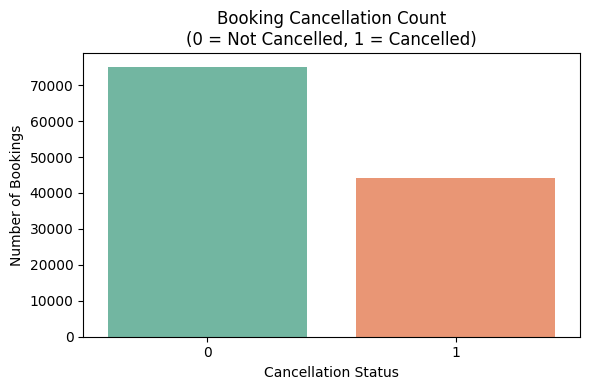

In [ ]:
# Cancellation distribution
print("Cancellation Rate:")
print(df['is_canceled'].value_counts())
print(f"\nOverall cancellation rate: {df['is_canceled'].mean()*100:.1f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='Set2')
plt.title('Booking Cancellation Count\n(0 = Not Cancelled, 1 = Cancelled)')
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

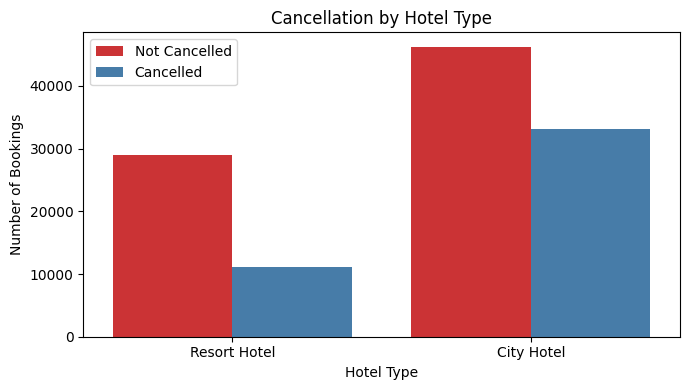

In [ ]:
# Cancellation by Hotel Type
plt.figure(figsize=(7, 4))
sns.countplot(x='hotel', hue='is_canceled', data=df, palette='Set1')
plt.title('Cancellation by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.legend(['Not Cancelled', 'Cancelled'])
plt.tight_layout()
plt.show()

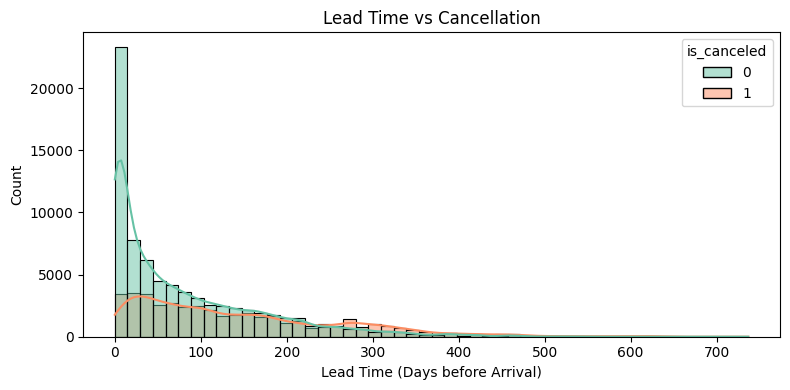

In [ ]:
# Lead Time vs Cancellation
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='lead_time', hue='is_canceled', bins=50, kde=True, palette='Set2')
plt.title('Lead Time vs Cancellation')
plt.xlabel('Lead Time (Days before Arrival)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

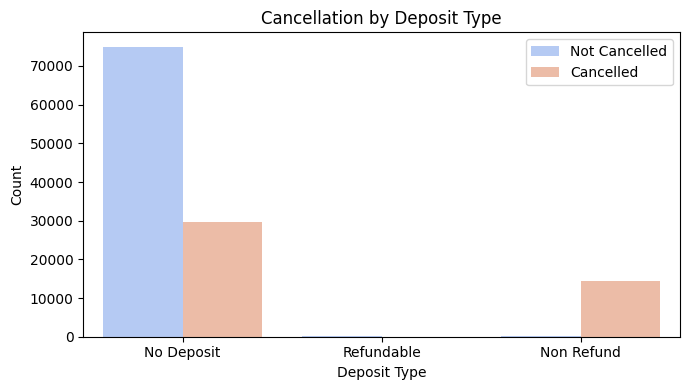

In [ ]:
# Cancellation by Deposit Type
plt.figure(figsize=(7, 4))
sns.countplot(x='deposit_type', hue='is_canceled', data=df, palette='coolwarm')
plt.title('Cancellation by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Count')
plt.legend(['Not Cancelled', 'Cancelled'])
plt.tight_layout()
plt.show()

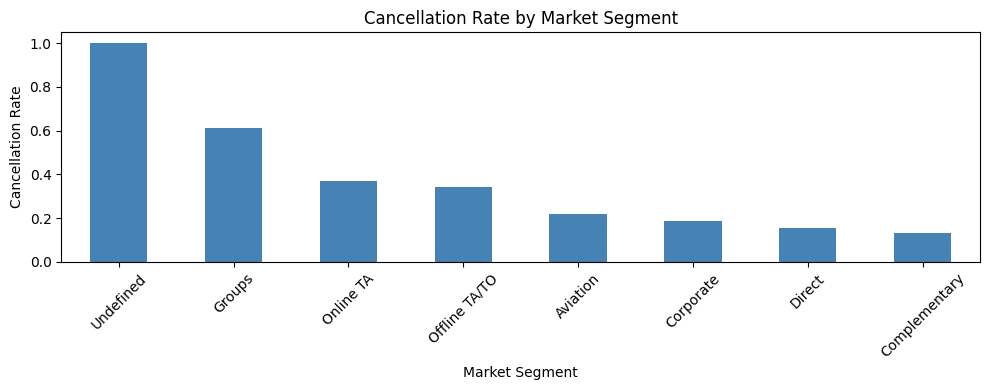

In [ ]:
# Cancellation by Market Segment
plt.figure(figsize=(10, 4))
cancel_rate = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)
cancel_rate.plot(kind='bar', color='steelblue')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

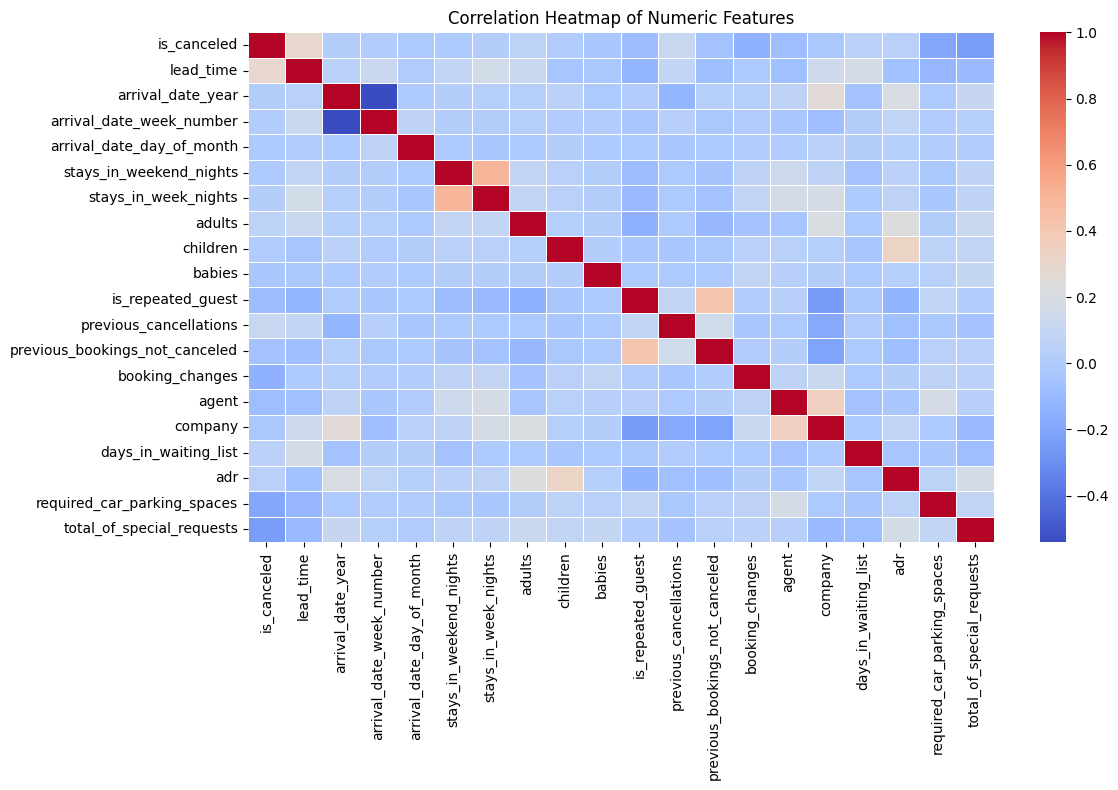

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
# Cleaning and preparing data for machine learning — key for LO2.
# Drop columns that leak the target variable
# 'reservation_status' directly says Canceled/Check-Out (data leakage!)
# 'reservation_status_date' is just a date string, not useful
df_clean = df.drop(columns=['reservation_status', 'reservation_status_date', 'company'])


print("Columns remaining:", df_clean.shape[1])

Columns remaining: 29


In [ ]:
# Check and remove duplicates
print("Duplicate records found:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Dataset shape after duplicate removal:", df_clean.shape)

Duplicate records found: 32260
Dataset shape after duplicate removal: (87130, 29)


In [ ]:
# Handle missing values
df_clean['children'].fillna(0, inplace=True)
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['agent'].fillna(0, inplace=True)


print("Missing values after cleaning:", df_clean.isnull().sum().sum())
print("No missing values remaining!")

Missing values after cleaning: 0
No missing values remaining!


In [ ]:
# Encode categorical (text) columns into numbers
label_enc = LabelEncoder()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns encoded:", cat_cols)

for col in cat_cols:
    df_clean[col] = label_enc.fit_transform(df_clean[col].astype(str))

print("\n✅ Encoding complete. Sample:")
df_clean.head(3)

Categorical columns encoded: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

✅ Encoding complete. Sample:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,1,0,342,2015,5,27,1,0,0,2,...,2,2,3,0,0.0,0,2,0.0,0,0
1,1,0,737,2015,5,27,1,0,0,2,...,2,2,4,0,0.0,0,2,0.0,0,0
2,1,0,7,2015,5,27,1,0,1,1,...,0,2,0,0,0.0,0,2,75.0,0,0


In [ ]:
# Dataset Prepared for Machine Learning
# Define Features (X) and Target (y)
X = df_clean.drop(columns=['is_canceled'])
y = df_clean['is_canceled']

print("Feature matrix (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Train-Test Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")

Feature matrix (X) shape: (87130, 28)
Target (y) shape: (87130,)

Training samples : 69,704
Testing samples  : 17,426


In [ ]:
#Three machine learning models are trained and compared — core of LO2.
# Helper function to evaluate any model
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"{'='*50}")
    print(f"  MODEL: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Cancelled', 'Cancelled']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Cancelled', 'Cancelled'],
                yticklabels=['Not Cancelled', 'Cancelled'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return model, acc, auc, y_prob

print("✅ evaluate_model() function ready!")

✅ evaluate_model() function ready!


  MODEL: Logistic Regression
  Accuracy : 0.7577  (75.77%)
  ROC-AUC  : 0.7575

Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.78      0.94      0.85     12673
    Cancelled       0.63      0.28      0.38      4753

     accuracy                           0.76     17426
    macro avg       0.70      0.61      0.62     17426
 weighted avg       0.74      0.76      0.72     17426



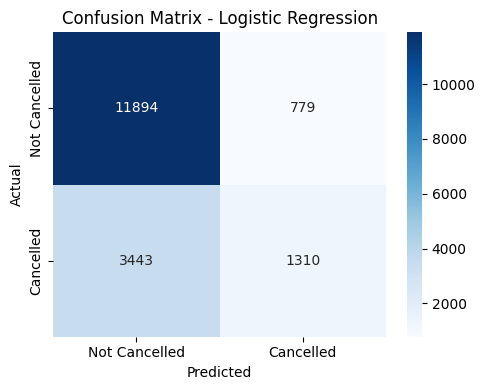

In [ ]:
#Model 1: Logistic Regression
#A simple baseline model — good for linearly separable problems.

lr_model, lr_acc, lr_auc, lr_prob = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=500, random_state=42),
    X_train, X_test, y_train, y_test
)

  MODEL: Decision Tree
  Accuracy : 0.8048  (80.48%)
  ROC-AUC  : 0.8620

Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.83      0.92      0.87     12673
    Cancelled       0.70      0.50      0.58      4753

     accuracy                           0.80     17426
    macro avg       0.77      0.71      0.73     17426
 weighted avg       0.79      0.80      0.79     17426



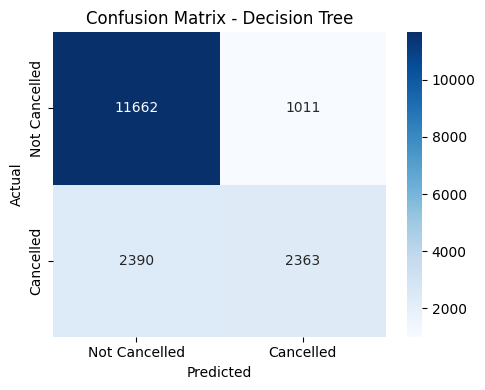

In [ ]:
#Model 2: Decision Tree
#Tree-based model that splits data using feature thresholds — easy to interpret.

dt_model, dt_acc, dt_auc, dt_prob = evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=8, random_state=42),
    X_train, X_test, y_train, y_test
)

  MODEL: Random Forest
  Accuracy : 0.8497  (84.97%)
  ROC-AUC  : 0.9095

Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.88      0.92      0.90     12673
    Cancelled       0.76      0.65      0.70      4753

     accuracy                           0.85     17426
    macro avg       0.82      0.79      0.80     17426
 weighted avg       0.85      0.85      0.85     17426



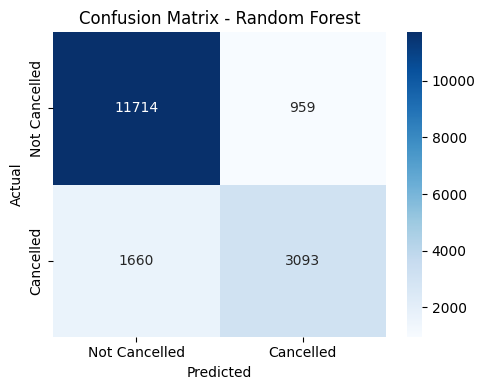

In [ ]:
#Model 3: Random Forest
#Ensemble of decision trees — typically the best performer for tabular data.

rf_model, rf_acc, rf_auc, rf_prob = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test
)

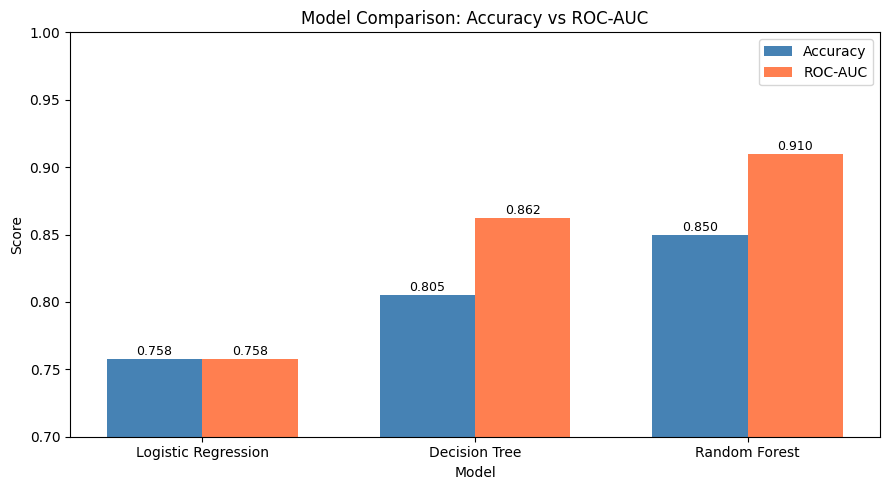

In [ ]:
# Comparing all three models side by side.
#Accuracy and AUC Bar Chart
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_acc, dt_acc, rf_acc]
aucs = [lr_auc, dt_auc, rf_auc]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, aucs, width, label='ROC-AUC', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy vs ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.7, 1.0)
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

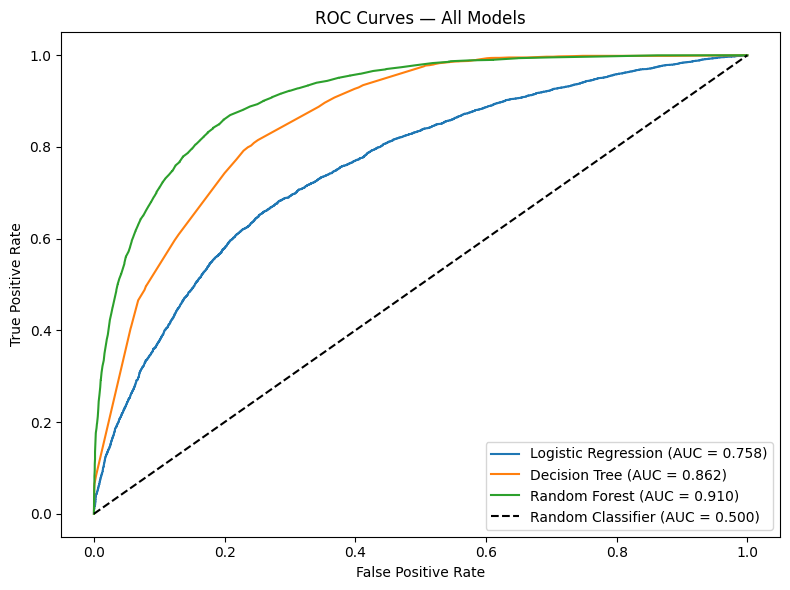

In [ ]:
# ROC Curves for all models
plt.figure(figsize=(8, 6))

for name, y_prob in [
    ('Logistic Regression', lr_prob),
    ('Decision Tree', dt_prob),
    ('Random Forest', rf_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

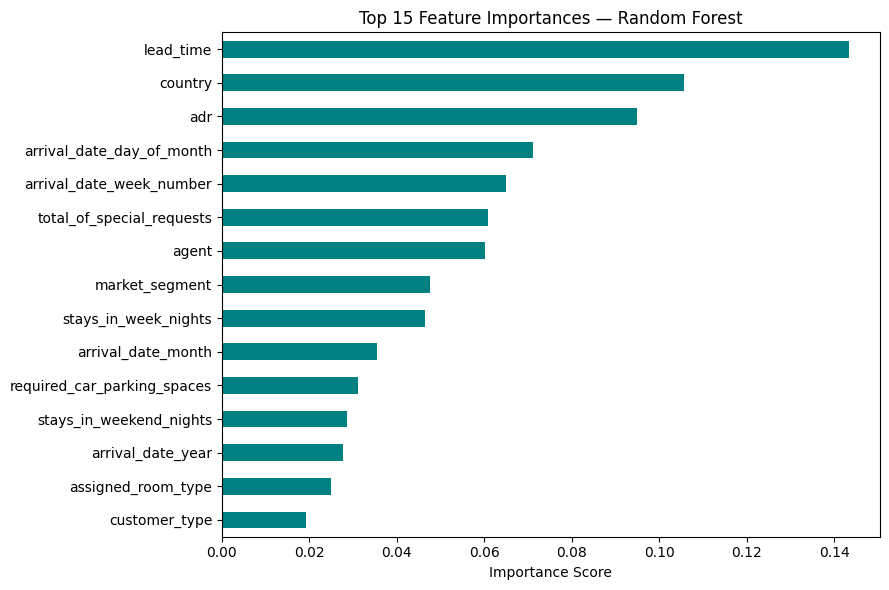


Top 10 Features Driving Cancellations:
lead_time                    0.143336
country                      0.105569
adr                          0.094911
arrival_date_day_of_month    0.071065
arrival_date_week_number     0.064882
total_of_special_requests    0.060788
agent                        0.060251
market_segment               0.047618
stays_in_week_nights         0.046373
arrival_date_month           0.035560


In [ ]:
#Which factors most influence cancellations? Important for LO3 (Big Data insights).

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
top_features.sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Features Driving Cancellations:")
print(top_features.head(10).to_string())